In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
# ==========================================
# GENERAL CONFIGURATION
# ==========================================
SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_DIR = Path("/content/drive/MyDrive/dataset")
MODELS_DIR = Path("/content/drive/MyDrive")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = ["aX", "aY", "aZ", "gX", "gY", "gZ"]

CLASS_FILES = {
    "idle": "idle.csv",
    "normal": "normal.csv",
    "high": "high.csv"
}

label_to_id = {label: idx for idx, label in enumerate(CLASS_FILES.keys())}
id_to_label = {idx: label for label, idx in label_to_id.items()}

WINDOW_SIZE = 100
STRIDE = 30

print("Dataset folder :", DATASET_DIR)
print("Models folder  :", MODELS_DIR)
print("Classes        :", label_to_id)

Dataset folder : /content/drive/MyDrive/dataset
Models folder  : /content/drive/MyDrive
Classes        : {'idle': 0, 'normal': 1, 'high': 2}


In [5]:
missing_files = []

for class_name, file_name in CLASS_FILES.items():
    file_path = DATASET_DIR / file_name
    if not file_path.exists():
        missing_files.append(str(file_path))

if missing_files:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing_files))

print("All dataset files found ✅")
print(list(DATASET_DIR.glob("*.csv")))

All dataset files found ✅
[PosixPath('/content/drive/MyDrive/dataset/high.csv'), PosixPath('/content/drive/MyDrive/dataset/idle.csv'), PosixPath('/content/drive/MyDrive/dataset/normal.csv')]


In [6]:
def load_imu_csv(csv_path, columns):
    df = pd.read_csv(csv_path)
    df = df[columns].dropna().reset_index(drop=True)
    return df.to_numpy(dtype=np.float32)

raw_signals = {}

for class_name, file_name in CLASS_FILES.items():
    file_path = DATASET_DIR / file_name
    raw_signals[class_name] = load_imu_csv(file_path, FEATURE_COLUMNS)
    print(f"{class_name}: {raw_signals[class_name].shape}")

idle: (4388, 6)
normal: (4414, 6)
high: (4366, 6)


In [7]:
for class_name, signal in raw_signals.items():
    print(f"\nClass: {class_name}")
    print("Shape:", signal.shape)
    print(signal[:5])


Class: idle
Shape: (4388, 6)
[[-0.191  0.023  0.953 -0.427  1.038 -0.061]
 [-0.188  0.026  0.954 -0.916  1.221  0.183]
 [-0.158  0.029  0.954 -0.549  1.648 -0.183]
 [-0.184  0.024  0.951 -0.793  1.77   0.366]
 [-0.183  0.021  0.953 -1.465  1.892 -0.366]]

Class: normal
Shape: (4414, 6)
[[-0.132 -0.045  0.967  1.282  1.16   1.892]
 [-0.087 -0.003  0.961  0.732  1.587  1.587]
 [-0.042  0.005  0.96   0.977  1.953  1.038]
 [-0.07  -0.033  0.967  0.977  1.709  1.953]
 [-0.066 -0.025  0.965  1.282  1.404  1.404]]

Class: high
Shape: (4366, 6)
[[-3.210e-01 -9.510e-01 -2.000e-03  3.845e+00  3.235e+00  4.272e+00]
 [-3.090e-01 -9.610e-01  1.300e-02  1.709e+00  3.479e+00  4.822e+00]
 [-2.980e-01 -9.710e-01  6.000e-03 -6.100e-02  3.296e+00  3.601e+00]
 [-2.800e-01 -9.500e-01  7.000e-03 -2.136e+00  5.005e+00  2.747e+00]
 [-3.310e-01 -9.580e-01  2.200e-02  2.625e+00  5.981e+00  3.235e+00]]


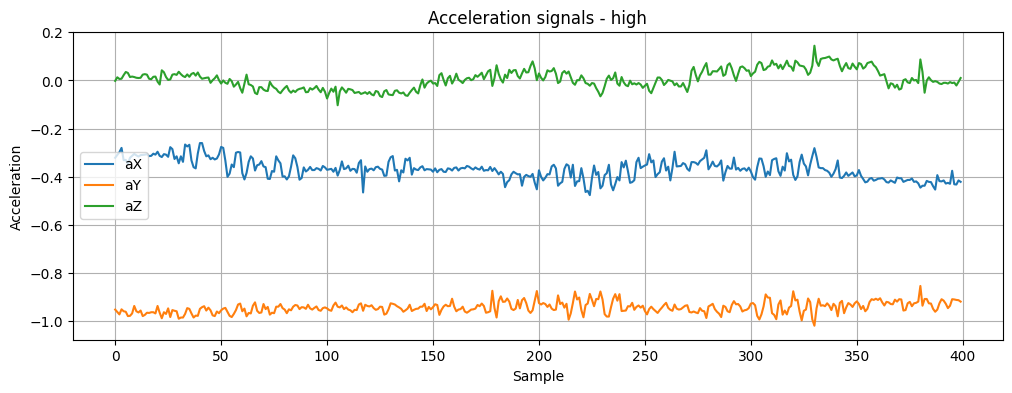

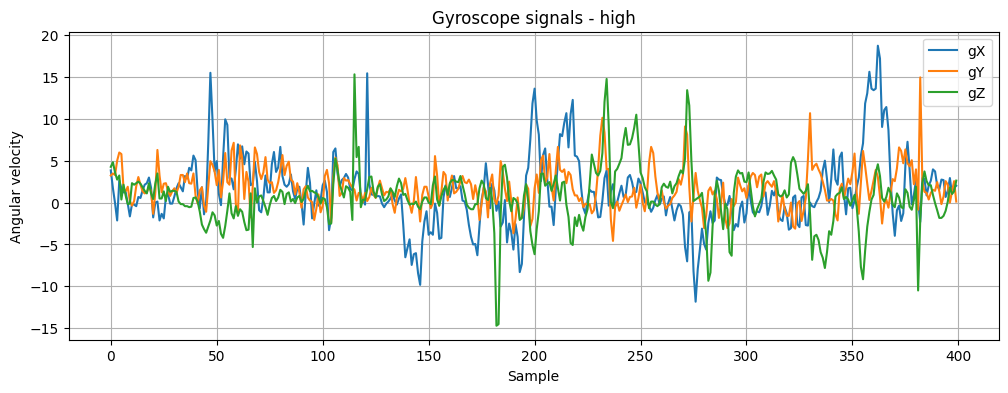

In [8]:
example_class = "high"
signal = raw_signals[example_class]

plt.figure(figsize=(12, 4))
plt.plot(signal[:400, 0], label="aX")
plt.plot(signal[:400, 1], label="aY")
plt.plot(signal[:400, 2], label="aZ")
plt.title(f"Acceleration signals - {example_class}")
plt.xlabel("Sample")
plt.ylabel("Acceleration")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(signal[:400, 3], label="gX")
plt.plot(signal[:400, 4], label="gY")
plt.plot(signal[:400, 5], label="gZ")
plt.title(f"Gyroscope signals - {example_class}")
plt.xlabel("Sample")
plt.ylabel("Angular velocity")
plt.grid()
plt.legend()
plt.show()

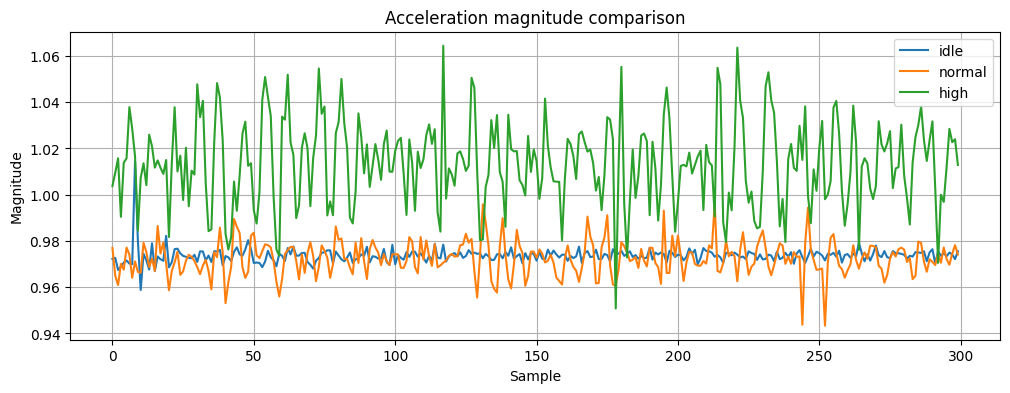

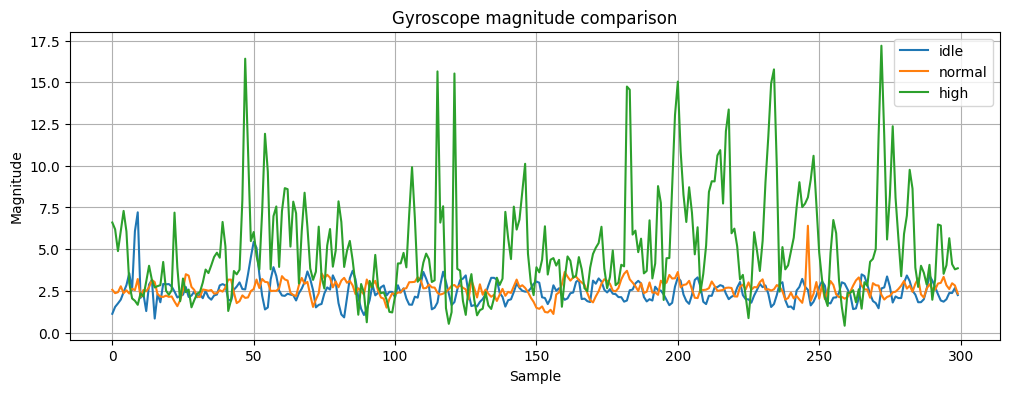

In [9]:
N = 300

plt.figure(figsize=(12, 4))
for class_name, signal in raw_signals.items():
    acc_mag = np.sqrt(signal[:N, 0]**2 + signal[:N, 1]**2 + signal[:N, 2]**2)
    plt.plot(acc_mag, label=class_name)

plt.title("Acceleration magnitude comparison")
plt.xlabel("Sample")
plt.ylabel("Magnitude")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
for class_name, signal in raw_signals.items():
    gyro_mag = np.sqrt(signal[:N, 3]**2 + signal[:N, 4]**2 + signal[:N, 5]**2)
    plt.plot(gyro_mag, label=class_name)

plt.title("Gyroscope magnitude comparison")
plt.xlabel("Sample")
plt.ylabel("Magnitude")
plt.grid()
plt.legend()
plt.show()

In [10]:
def create_windows(signal, window_size=100, stride=30):
    windows = []
    n_samples = signal.shape[0]

    for start in range(0, n_samples - window_size + 1, stride):
        end = start + window_size
        windows.append(signal[start:end])

    if len(windows) == 0:
        return np.zeros((0, window_size, signal.shape[1]), dtype=np.float32)

    return np.stack(windows).astype(np.float32)

In [11]:
def extract_window_features(window):
    acc = window[:, 0:3]
    gyro = window[:, 3:6]

    acc_mag = np.sqrt(np.sum(acc ** 2, axis=1))
    gyro_mag = np.sqrt(np.sum(gyro ** 2, axis=1))

    mean_acc = np.mean(acc_mag)
    std_acc = np.std(acc_mag)
    range_acc = np.max(acc_mag) - np.min(acc_mag)

    mean_gyro = np.mean(gyro_mag)
    std_gyro = np.std(gyro_mag)
    range_gyro = np.max(gyro_mag) - np.min(gyro_mag)

    return np.array([
        mean_acc,
        std_acc,
        range_acc,
        mean_gyro,
        std_gyro,
        range_gyro
    ], dtype=np.float32)

In [12]:
def build_feature_dataset(raw_signals, label_to_id, window_size=100, stride=30):
    X_list = []
    y_list = []

    for class_name, class_id in label_to_id.items():
        signal = raw_signals[class_name]
        windows = create_windows(signal, window_size=window_size, stride=stride)

        print(f"{class_name}: {len(windows)} windows")

        for window in windows:
            features = extract_window_features(window)
            X_list.append(features)
            y_list.append(class_id)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)

    return X, y

X, y = build_feature_dataset(
    raw_signals=raw_signals,
    label_to_id=label_to_id,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

print("X shape:", X.shape)
print("y shape:", y.shape)

idle: 143 windows
normal: 144 windows
high: 143 windows
X shape: (430, 6)
y shape: (430,)


In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (258, 6) (258,)
Val  : (86, 6) (86,)
Test : (86, 6) (86,)


In [14]:
feature_mean = np.mean(X_train, axis=0)
feature_std = np.std(X_train, axis=0) + 1e-6

X_train = (X_train - feature_mean) / feature_std
X_val   = (X_val   - feature_mean) / feature_std
X_test  = (X_test  - feature_mean) / feature_std

np.save(MODELS_DIR / "mean.npy", feature_mean)
np.save(MODELS_DIR / "std.npy", feature_std)

print("Normalization saved ✅")
print("mean:", feature_mean)
print("std :", feature_std)

Normalization saved ✅
mean: [ 0.9864761   0.01123473  0.06642538  3.6562011   1.8948456  10.406062  ]
std : [1.8542960e-02 9.3251485e-03 5.2861150e-02 1.7331318e+00 2.3537166e+00
 1.2178314e+01]


In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(24, activation="relu"),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dense(len(CLASS_FILES), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 507 (1.98 KB)

 Trainable params: 507 (1.98 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=8,
    verbose=1
)

Epoch 1/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5200 - loss: 1.1402 - val_accuracy: 0.6395 - val_loss: 1.0205
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6032 - loss: 1.0326 - val_accuracy: 0.7791 - val_loss: 0.9201
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7051 - loss: 0.9250 - val_accuracy: 0.8140 - val_loss: 0.7994
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7515 - loss: 0.8084 - val_accuracy: 0.8488 - val_loss: 0.6732
Epoch 5/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8198 - loss: 0.6897 - val_accuracy: 0.8721 - val_loss: 0.5559
Epoch 6/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8469 - loss: 0.5696 - val_accuracy: 0.8837 - val_loss: 0.4548
Epoch 7/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8852 - loss: 0.4631 - val_accuracy: 0.9302 - val_loss: 0.3707
Epoch 8/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9085 - loss: 0.3811 - val_accuracy: 0.9535 - val_loss:

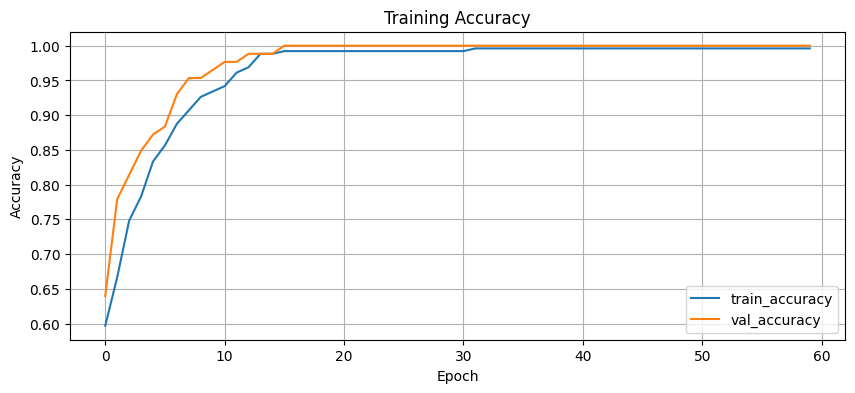

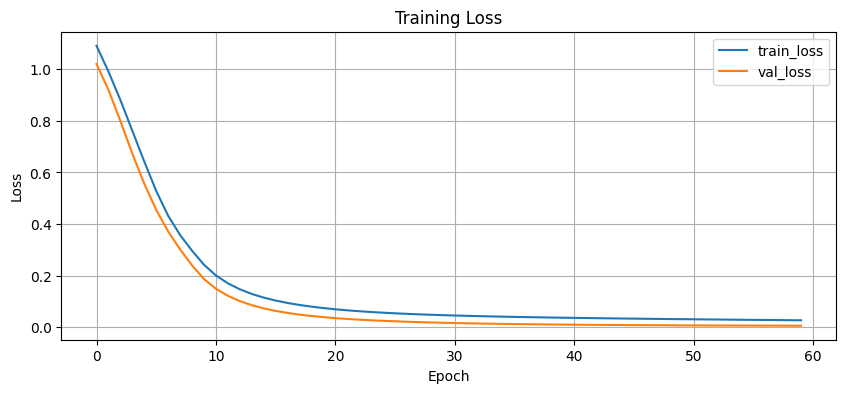

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

In [18]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

Test accuracy: 1.0
Test loss: 0.006706193555146456


In [19]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=list(CLASS_FILES.keys())))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Confusion matrix:
[[29  0  0]
 [ 0 29  0]
 [ 0  0 28]]

Classification report:
              precision    recall  f1-score   support

        idle       1.00      1.00      1.00        29
      normal       1.00      1.00      1.00        29
        high       1.00      1.00      1.00        28

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86



In [20]:
keras_path = MODELS_DIR / "vibration_idle_normal_high.keras"
model.save(keras_path)
print("Keras model saved:", keras_path)

Keras model saved: /content/drive/MyDrive/vibration_idle_normal_high.keras


In [21]:
keras_path = MODELS_DIR / "vibration_idle_normal_high.keras"
model.save(keras_path)
print("Keras model saved:", keras_path)

Keras model saved: /content/drive/MyDrive/vibration_idle_normal_high.keras


In [22]:
tflite_path = MODELS_DIR / "vibration_idle_normal_high.tflite"

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("TFLite model saved ✅")
print("Path:", tflite_path)
print("Size:", len(tflite_model), "bytes")

Saved artifact at '/tmp/tmpjkx34s35'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133089550016848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133089550018000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133089550016656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133089550015312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133089550018576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133089550015504: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved ✅
Path: /content/drive/MyDrive/vibration_idle_normal_high.tflite
Size: 4148 bytes


In [23]:
MODEL_PATH = MODELS_DIR / "vibration_idle_normal_high.tflite"
HEADER_PATH = MODELS_DIR / "model_data.h"

model_bytes = MODEL_PATH.read_bytes()

with open(HEADER_PATH, "w", encoding="utf-8") as f:
    f.write("// Auto-generated TensorFlow Lite model\n")
    f.write("#pragma once\n\n")
    f.write("const unsigned char model_data[] = {\n")

    for i, b in enumerate(model_bytes):
        f.write(f"0x{b:02x}, ")
        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write("\n};\n")
    f.write(f"const unsigned int model_data_len = {len(model_bytes)};\n")

print("model_data.h generated ✅")
print("Path:", HEADER_PATH)

model_data.h generated ✅
Path: /content/drive/MyDrive/model_data.h


In [24]:
labels_path = MODELS_DIR / "labels.txt"

with open(labels_path, "w", encoding="utf-8") as f:
    for label in CLASS_FILES.keys():
        f.write(label + "\n")

print("labels.txt saved:", labels_path)

labels.txt saved: /content/drive/MyDrive/labels.txt
